# Análise Exploratória - Situações de Discentes

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
try:
    df = pd.read_csv('../../1-limpeza-de-dados/databases/situacoes-discentes.csv', sep=';')
except Exception as e:
    print('erro ao carregar o arquivo:', e)

df.head()

,id_discente,ano_ingresso,periodo_ingresso,nivel_ensino,id_curso,curso,situacao,ano_alteracao_situacao,periodo_alteracao_situacao
0,95b630b35d0a73eb80abecb0b81d88e4,2013,1,GRADUAÇÃO,2000009,CIÊNCIAS BIOLÓGICAS,CADASTRADO,2013,1
1,8676f69f4498bda522957728d3038b0c,2013,1,GRADUAÇÃO,2000009,CIÊNCIAS BIOLÓGICAS,CADASTRADO,2013,1
2,bccad621a9d3117581ceee8deec55894,2013,1,GRADUAÇÃO,2000009,CIÊNCIAS BIOLÓGICAS,CADASTRADO,2013,1
3,2e9617e34b8dd84eb6626da3a88ad63e,2013,1,GRADUAÇÃO,2000009,CIÊNCIAS BIOLÓGICAS,CADASTRADO,2013,1
4,7ab14073c07da9d13120955b9a4d03f2,2013,1,GRADUAÇÃO,2000009,CIÊNCIAS BIOLÓGICAS,CADASTRADO,2013,1


In [26]:
print('Tipos de dado e valores nulos:')
print(df.info())

print('\nResumo estatístico (numérico):')
print(df.describe(include=[np.number]).T)

Tipos de dado e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951714 entries, 0 to 951713
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   id_discente                 951714 non-null  object
 1   ano_ingresso                951714 non-null  int64 
 2   periodo_ingresso            951714 non-null  int64 
 3   nivel_ensino                951714 non-null  object
 4   id_curso                    951714 non-null  int64 
 5   curso                       951714 non-null  object
 6   situacao                    951714 non-null  object
 7   ano_alteracao_situacao      951714 non-null  int64 
 8   periodo_alteracao_situacao  951714 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 65.3+ MB
None

Resumo estatístico (numérico):
                               count          mean           std        min        25%        50%         75%          max
ano_ingresso         

## 1) Distribuição das situações dos discentes

gráfico de distribuição das categorias na coluna `situacao`.

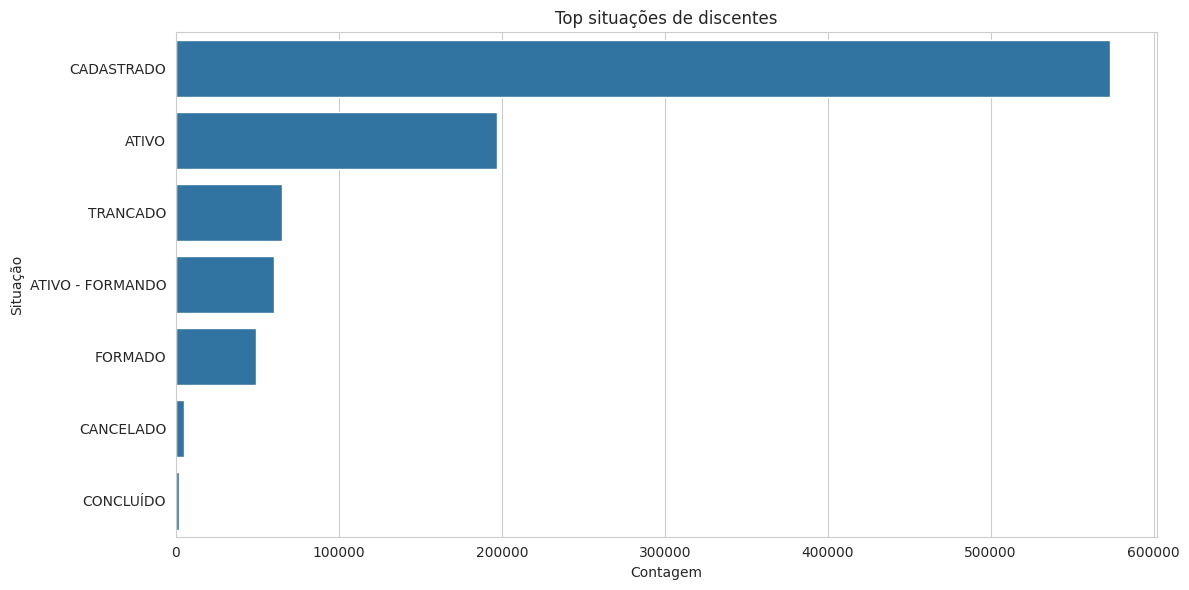

In [28]:
# aqui to contanto as situações
vc_sit = df['situacao'].value_counts(dropna=False)
vc_sit_top = vc_sit.head(20)
vc_sit_top

plt.figure(figsize=(12,6))
sns.barplot(x=vc_sit_top.values, y=vc_sit_top.index)
plt.title('Top situações de discentes')
plt.xlabel('Contagem')
plt.ylabel('Situação')
plt.tight_layout()
plt.show()

## 2) Cursos com maior número de registros

Ver quais cursos concentram mais registros pode indicar cursos com maior rotatividade ou maior número de alunos.

curso
CIÊNCIAS E TECNOLOGIA           139868
PEDAGOGIA                        40921
TECNOLOGIA DA INFORMAÇÃO         34887
ADMINISTRAÇÃO                    33038
DIREITO                          31553
CIÊNCIAS CONTÁBEIS               29336
GEOGRAFIA                        26168
FARMÁCIA                         25808
HISTÓRIA                         25214
CIÊNCIAS BIOLÓGICAS              23645
MATEMÁTICA                       20400
QUÍMICA                          19610
ENFERMAGEM                       19142
NUTRIÇÃO                         16956
GESTÃO DE POLÍTICAS PÚBLICAS     16828
EDUCAÇÃO FÍSICA                  16287
TURISMO                          14901
MEDICINA                         14899
ENGENHARIA CIVIL                 14737
FISIOTERAPIA                     14178
Name: count, dtype: int64

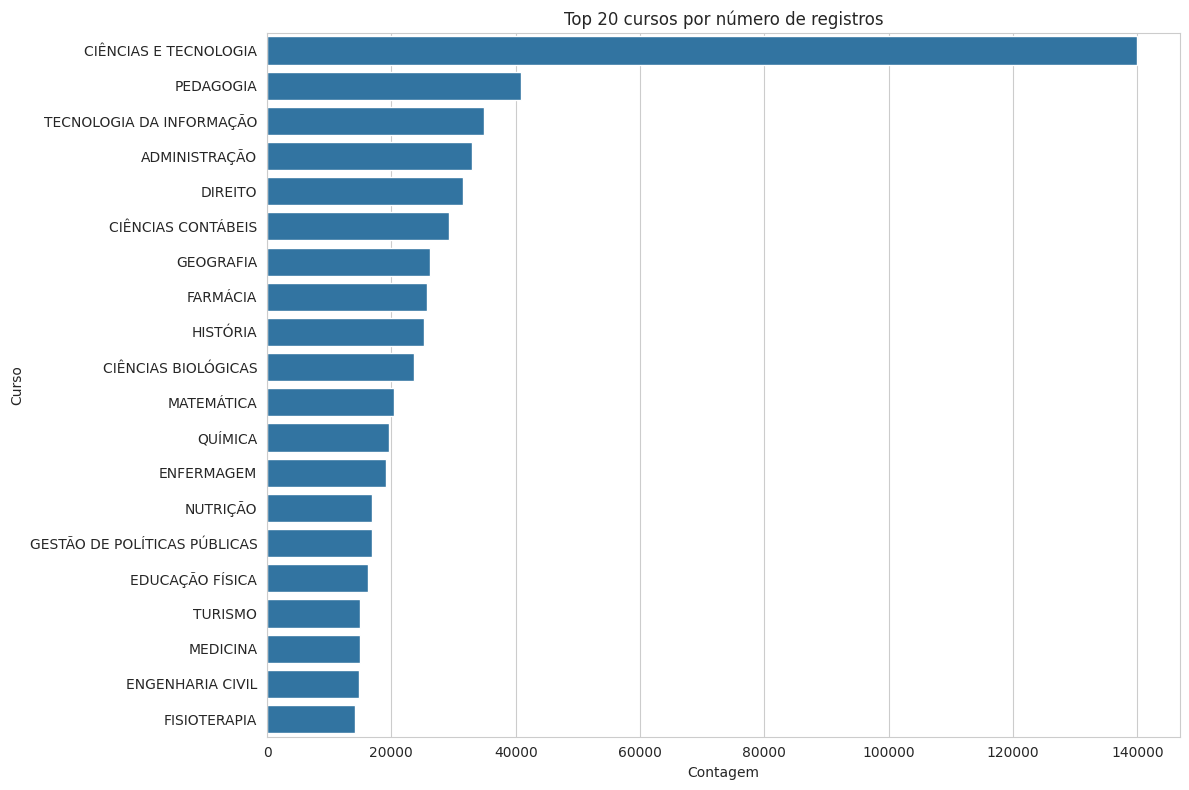

In [29]:
# top cursos (eu já imaginava que C&T tinha muita gente, mas me supreendeu essa proporção)
if 'curso' in df.columns:
    top_courses = df['curso'].value_counts().head(20)
    display(top_courses)
    plt.figure(figsize=(12,8))
    sns.barplot(x=top_courses.values, y=top_courses.index)
    plt.title('Top 20 cursos por número de registros')
    plt.xlabel('Contagem')
    plt.ylabel('Curso')
    plt.tight_layout()
    plt.show()
else:
    print('Coluna "curso" não encontrada no dataset.')

## 3) Distribuição por ano de ingresso e ano de alteração de situação

analisa a distribuição dos anos e nos ajuda a identificar se há concentrações em certos períodos (ex: aumento de ingressos, efeitos da pandemia etc etc).


Distribuição da coluna: ano_ingresso


ano_ingresso
1974     2
1975     3
1979     1
1980    12
1981     4
1982    16
1983    19
1984    15
1985    20
1986    16
Name: count, dtype: int64

ano_ingresso
2016    78771
2017    87904
2018    76669
2019    69823
2020    63443
2021    66745
2022    54187
2023    57671
2024    45815
2025       54
Name: count, dtype: int64

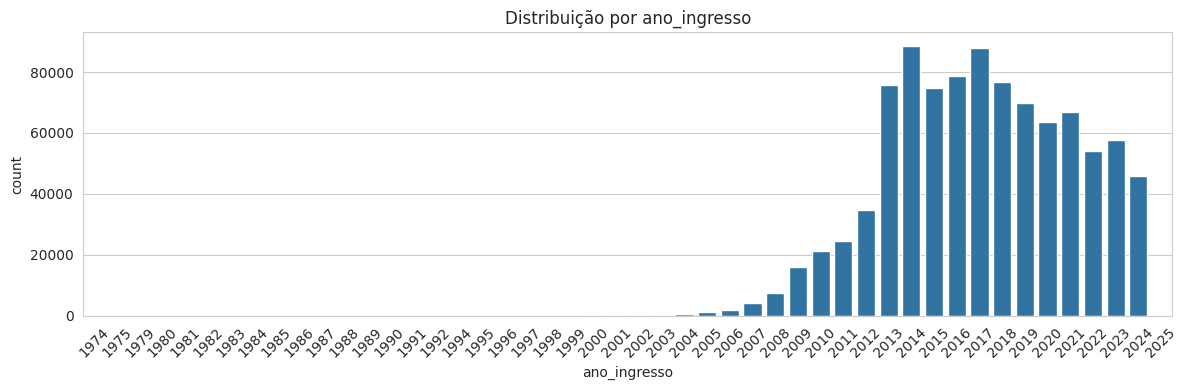


Distribuição da coluna: ano_alteracao_situacao


ano_alteracao_situacao
2013    75628
2014    85831
2015    77452
2016    82925
2017    87930
2018    80928
2019    77291
2020    71211
2021    74724
2022    72187
Name: count, dtype: int64

ano_alteracao_situacao
2015    77452
2016    82925
2017    87930
2018    80928
2019    77291
2020    71211
2021    74724
2022    72187
2023    89850
2024    75757
Name: count, dtype: int64

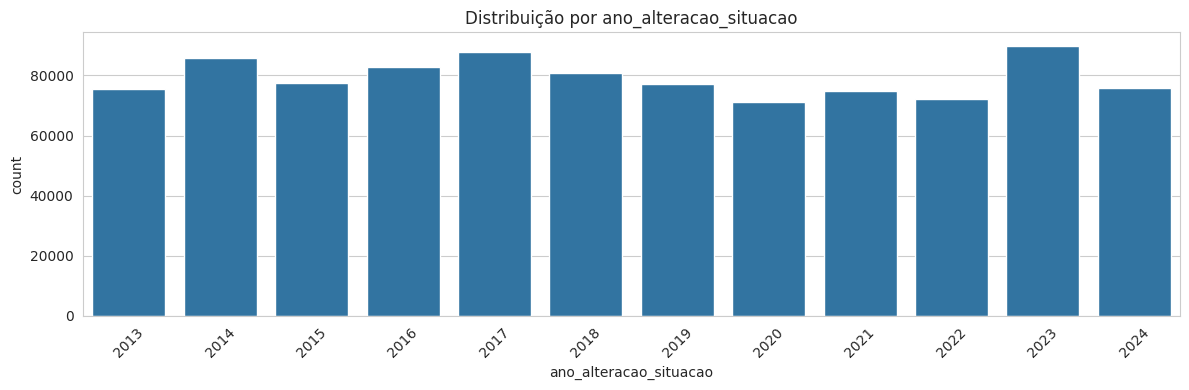

In [32]:
# conversões e plots de anos (se existirem)
for col in ['ano_ingresso', 'ano_alteracao_situacao']:
    if col in df.columns:
        print('\nDistribuição da coluna:', col)
        display(df[col].value_counts().sort_index().head(10))
        display(df[col].value_counts().sort_index().tail(10))
        plt.figure(figsize=(12,4))
        sns.countplot(x=col, data=df, order=sorted(df[col].dropna().unique()))
        plt.title(f'Distribuição por {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # print("debug")
        # print(df.columns)
    else:
        print(f'Coluna {col} não encontrada.')

## 4) Evolução temporal das situações (ano_alteracao_situacao × situacao)

o objetivo aqui é criar uma tabela pivô com contagens de `situacao` por `ano_alteracao_situacao` e plotar linhas para as principais categorias

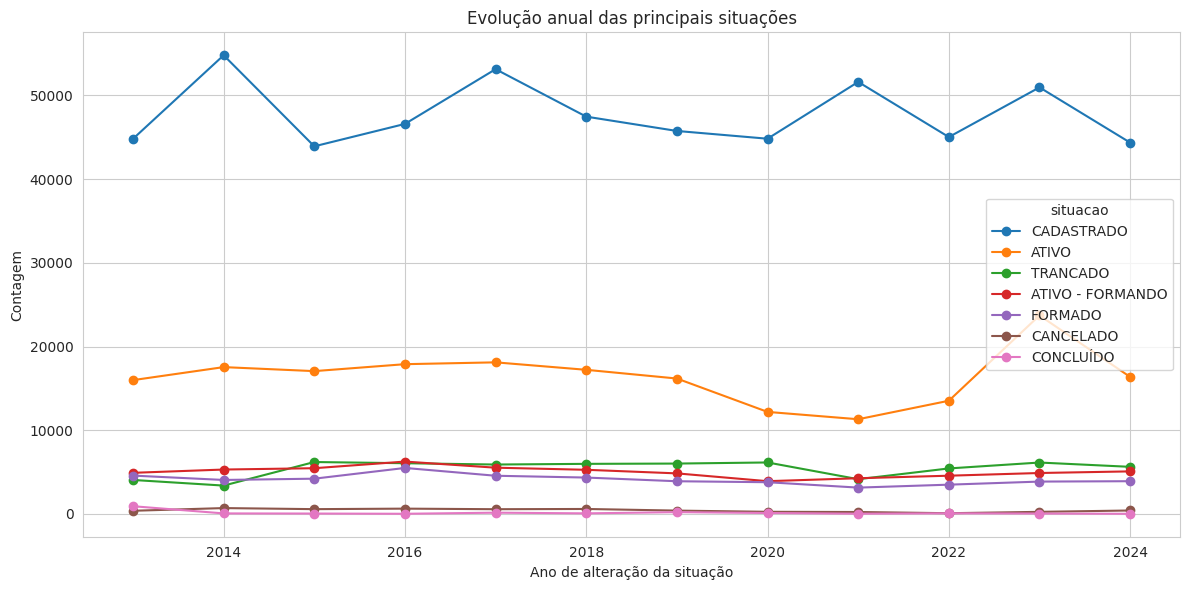

In [38]:
# pivô e plot da evolução temporal
if ('ano_alteracao_situacao' in df.columns) and ('situacao' in df.columns):
    pivot = df.pivot_table(index='ano_alteracao_situacao', columns='situacao', values='id_discente', aggfunc='count', fill_value=0)
    # selecionar top N situações por soma total
    top_situ = pivot.sum().sort_values(ascending=False).head(8).index.tolist()
    pivot_top = pivot[top_situ]
    pivot_top.plot(kind='line', marker='o', figsize=(12,6))
    plt.title('Evolução anual das principais situações')
    plt.xlabel('Ano de alteração da situação')
    plt.ylabel('Contagem')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('Colunas necessárias para a análise temporal não foram encontradas.')

## 5) Cruzamento: situação × período (ex: 1/2)

aqui vamos verificar se há sazonalidade dentro do ano (período .1 vs .2).

periodo_alteracao_situacao
1    576203
2    375511
dtype: int64

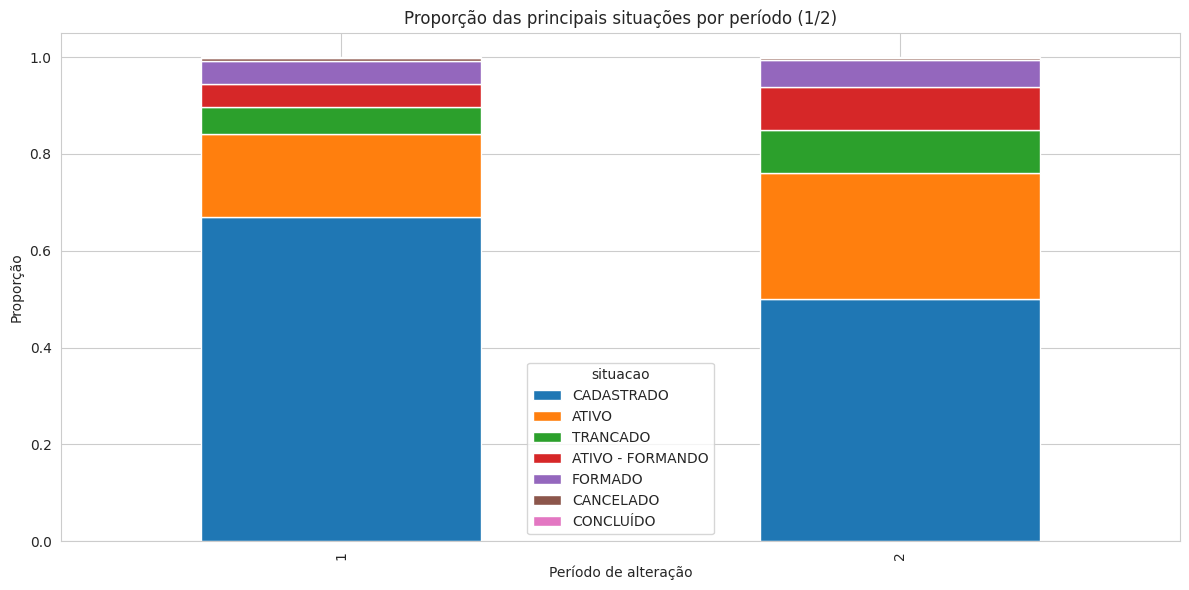

In [37]:
if ('periodo_alteracao_situacao' in df.columns) and ('situacao' in df.columns):
    ct = pd.crosstab(df['periodo_alteracao_situacao'], df['situacao'])
    display(ct.sum(axis=1))
    # plot das proporções das top situações
    top_situ = df['situacao'].value_counts().head(8).index
    ct_top = ct[top_situ]
    ct_top_norm = ct_top.div(ct_top.sum(axis=1), axis=0)
    ct_top_norm.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title('Proporção das principais situações por período (1/2)')
    plt.xlabel('Período de alteração')
    plt.ylabel('Proporção')
    plt.tight_layout()
    plt.show()
else:
    print('Colunas para cruzamento não encontradas.')